(sec:model_reduction)=
# Model Reduction
This notebook will demonstrate the capabilities of SDynPy for performing reduction and assembly of component models.

Models of the wing, fuselage, and tail of the airplane will be reduced in size using Guyan, Dynamic, Craig-Bampton, and Modal reductions.  These reduced models will then be assembled into the final airplane system and compared to the assembled full models, which will provide truth data.  Accuracy of the model will be investigated for each structure.

## Imports
The first step will be to import the SDynPy module, as well as its `demo` package to get the airplane components.  We will also import Matplotlib for plotting purposes and NumPy for numerical computations.

In [1]:
import sdynpy as sdpy
import sdynpy.demo as demo
import numpy as np
import matplotlib.pyplot as plt

## Set up 3D Plots
We will now set up default parameters for plotting the airplane.

In [2]:
plot_kwargs = {'node_size':3,'line_width':2,'view_from':[-1,1,1]}

## Collect and Set Up Models
We will now collect the component models from the `beam_airplane` demonstration, and investigate to see what components are available.

In [3]:
demo.beam_airplane.component_systems

{'fuselage': System with 126 DoFs (126 internal DoFs),
 'wing': System with 492 DoFs (492 internal DoFs),
 'tail': System with 60 DoFs (60 internal DoFs),
 'transmission_simulator': System with 132 DoFs (132 internal DoFs)}

For this work, we will only use the `fuselage`, `wing`, and `tail`.

In [4]:
names = ['fuselage','wing','tail']
system = {name:demo.beam_airplane.component_systems[name] for name in names}
geometry = {name:demo.beam_airplane.component_geometries[name] for name in names}

Since all the components have nodes starting at ID 1, we need to offset these node IDs so they do not conflict when we combine the systems together for substructuring.

The easiest way to increment the nodes in the geometry is to use the [`modify_ids`](#api:sdynpy.Geometry.modify_ids) method, which will also increment the references to the node IDs in the tracelines.  The system object's nodes can be incremented directly.  We will also plot each component's geometry with degrees of freedom labeled at this time, which will help us select degrees of freedom to keep in the future reductions.

In [5]:
for i,name in enumerate(names):
    increment = 100*(i+1) # We will add a 100s place to each node, 1XX for fuselage, 2XX for wing, 3XX for tail
    geometry[name] = geometry[name].modify_ids(node_change = increment)
    system[name].coordinate.node += increment
    geometry[name].plot(label_nodes=True, **plot_kwargs)

|Fuselage Nodes|Wing Nodes|Tail Nodes|
|---|---|---|
|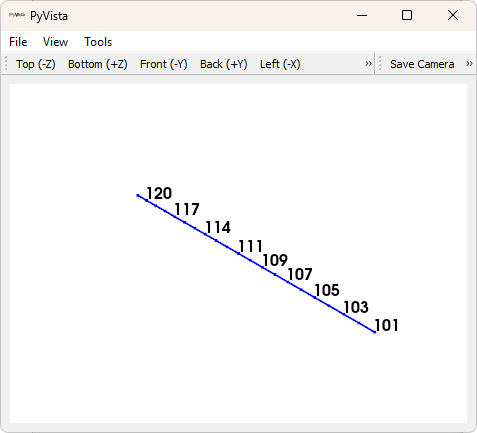|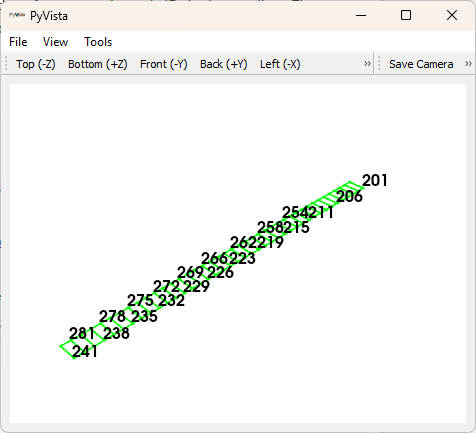|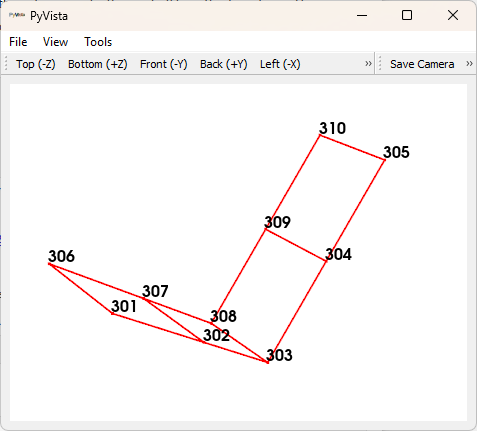|

We will also go ahead and compute the mode shape for each component up to a maximum frequency of interest.

In [6]:
maximum_frequency = 100
component_shapes = {name:system[name].eigensolution(maximum_frequency=maximum_frequency) for name in names}

## Creating Truth Data

We can create truth data by combining the un-reduced models together.  Because the airplane geometry in the `beam_airplane` demo is constructed such that nodes that should be connected are co-located, we can use SDynPy's substructuring function [`substructure_by_position`](#api:sdynpy.System.substructure_by_position) to combine the un-reduced systems.  We will then compute the modes of this combined system.

In [7]:
full_system,full_geometry = sdpy.system.substructure_by_position([system[name] for name in names],
                                                                 [geometry[name] for name in names])
full_shapes = full_system.eigensolution(maximum_frequency=maximum_frequency)

It is useful at this point to plot the shapes to ensure that the constraints have been applied correctly.  For example, the boundaries between wing and fuselage the boundaries between fuselage and tail should move together for all mode shapes.

In [8]:
full_geometry.plot_shape(full_shapes,plot_kwargs=plot_kwargs);

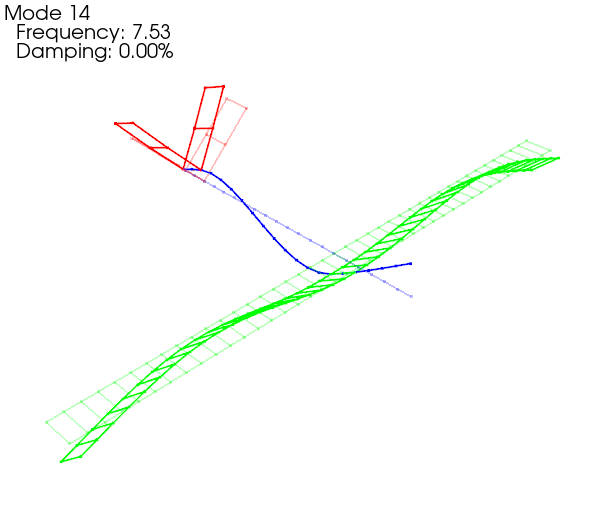

Indeed, the wing and tail move along with the fuselage, so the constraints have been applied successfully.

## Selecting Degrees of Freedom for Reduction and Substructuring

At this point, we can select the degrees of freedom that will be kept in the reduction.  This will include any boundary degrees of freedom used in the substructuring, as well as any internal degrees of freedom that will be kept to preserve the dynamics of the system.  We can pick these quantities from the geometry plots we just created of the geometry.

For the fuselage, we will select every other node and only keep the translational degrees of freedom.  For the wing, we will keep every fourth node and only keep the translational degrees of freedom.  For the tail, we will keep the boundary and tip nodes and only keep the translational degrees of freedom.

In [9]:
# Boundary degrees of freedom
wing_boundary_dofs = sdpy.coordinate_array([105,107,221,262],[1,2,3,4,5,6],force_broadcast=True)
tail_boundary_dofs = sdpy.coordinate_array([119,121,303,308],[1,2,3,4,5,6],force_broadcast=True)
all_boundary_dofs = np.unique(np.concatenate((wing_boundary_dofs,tail_boundary_dofs)))

# Internal Degrees of Freedom
internal_dofs = np.concatenate((
    sdpy.coordinate_array([101,103,105,107,109,113,115,117,119,121],[1,2,3],force_broadcast=True),
    sdpy.coordinate_array(geometry['wing'].node.id[::4],[1,2,3],force_broadcast=True),
    sdpy.coordinate_array([301,303,305,306,308,310],[1,2,3],force_broadcast=True)))

# Kept dofs are combination of internal and boundary degrees of freedom
reduction_dofs = np.unique(np.concatenate((internal_dofs,wing_boundary_dofs,tail_boundary_dofs)))

# Look at the entire list of dofs to keep.
reduction_dofs

coordinate_array(string_array=
array(['101X+', '101Y+', '101Z+', '103X+', '103Y+', '103Z+', '105X+',
       '105Y+', '105Z+', '105RX+', '105RY+', '105RZ+', '107X+', '107Y+',
       '107Z+', '107RX+', '107RY+', '107RZ+', '109X+', '109Y+', '109Z+',
       '113X+', '113Y+', '113Z+', '115X+', '115Y+', '115Z+', '117X+',
       '117Y+', '117Z+', '119X+', '119Y+', '119Z+', '119RX+', '119RY+',
       '119RZ+', '121X+', '121Y+', '121Z+', '121RX+', '121RY+', '121RZ+',
       '201X+', '201Y+', '201Z+', '205X+', '205Y+', '205Z+', '209X+',
       '209Y+', '209Z+', '213X+', '213Y+', '213Z+', '217X+', '217Y+',
       '217Z+', '221X+', '221Y+', '221Z+', '221RX+', '221RY+', '221RZ+',
       '225X+', '225Y+', '225Z+', '229X+', '229Y+', '229Z+', '233X+',
       '233Y+', '233Z+', '237X+', '237Y+', '237Z+', '241X+', '241Y+',
       '241Z+', '245X+', '245Y+', '245Z+', '249X+', '249Y+', '249Z+',
       '253X+', '253Y+', '253Z+', '257X+', '257Y+', '257Z+', '261X+',
       '261Y+', '261Z+', '262X+', '262Y+', '

## Perform the model reductions

In this step, we will perform the model reductions and assembly.  We will perform Guyan, Dynamic, Craig-Bampton, and Component Mode reductions for this work, and then evaluate which technique works the best.

### Guyan Reduction
Guyan reduction forms the reduction transformation matrix using the stiffness matrix of the system.  It is referred to as Static reduction because the transformation does not take into account any mass effects.

The formula for the transformation is:

$$ \mathbf{T} = \begin{bmatrix} \mathbf{I} \\ -{\mathbf{K}_{dd}}^{-1}\mathbf{K}_{da}\end{bmatrix}$$

where the $a$-set degrees of freedom are the kept degrees of freedom in `reduction_dofs`, and the $d$-set degrees of freedom are the discarded set.

Guyan reduction can be easily performed in SDynPy by using the [`reduce_guyan`](#api:sdynpy.System.reduce_guyan) method of the [`System`](#api:sdynpy.System) object.  The reduced systems can be combined identically to the full system by using the [`substructure_by_position`](#api:sdynpy.System.substructure_by_position) function, because SDynPy [`System`](#api:sdynpy.System) objects track transformations that have been applied to them and apply those effects during calculations.  We can interrogate the combined system to understand how many degrees of freedom remain in the model; in this case, our original model of 678 degrees of freedom has been reduced to only 114 degrees of freedom due to the reduction.

In [10]:
# Set up dictionaries to contain our reduced systems and mode shapes
system_guyan = {}
component_shapes_guyan = {}
# Perform Guyan reduction for each component
for name,system_i in system.items():
    dofs = reduction_dofs[np.isin(reduction_dofs,system_i.coordinate)]
    system_guyan[name] = system_i.reduce_guyan(dofs)
    # Compute modes and compare to original system
    component_shapes_guyan[name] = system_guyan[name].eigensolution(maximum_frequency=maximum_frequency)
    
# Perform substructuring
full_system_guyan,full_geometry_guyan = sdpy.system.substructure_by_position(
    [system_guyan[name] for name in names],
    [geometry[name] for name in names])
full_shapes_guyan = full_system_guyan.eigensolution(maximum_frequency=maximum_frequency)

full_system_guyan

System with 678 DoFs (114 internal DoFs)

We can compare the results against the truth data previously generated to see how the accuracy compares.

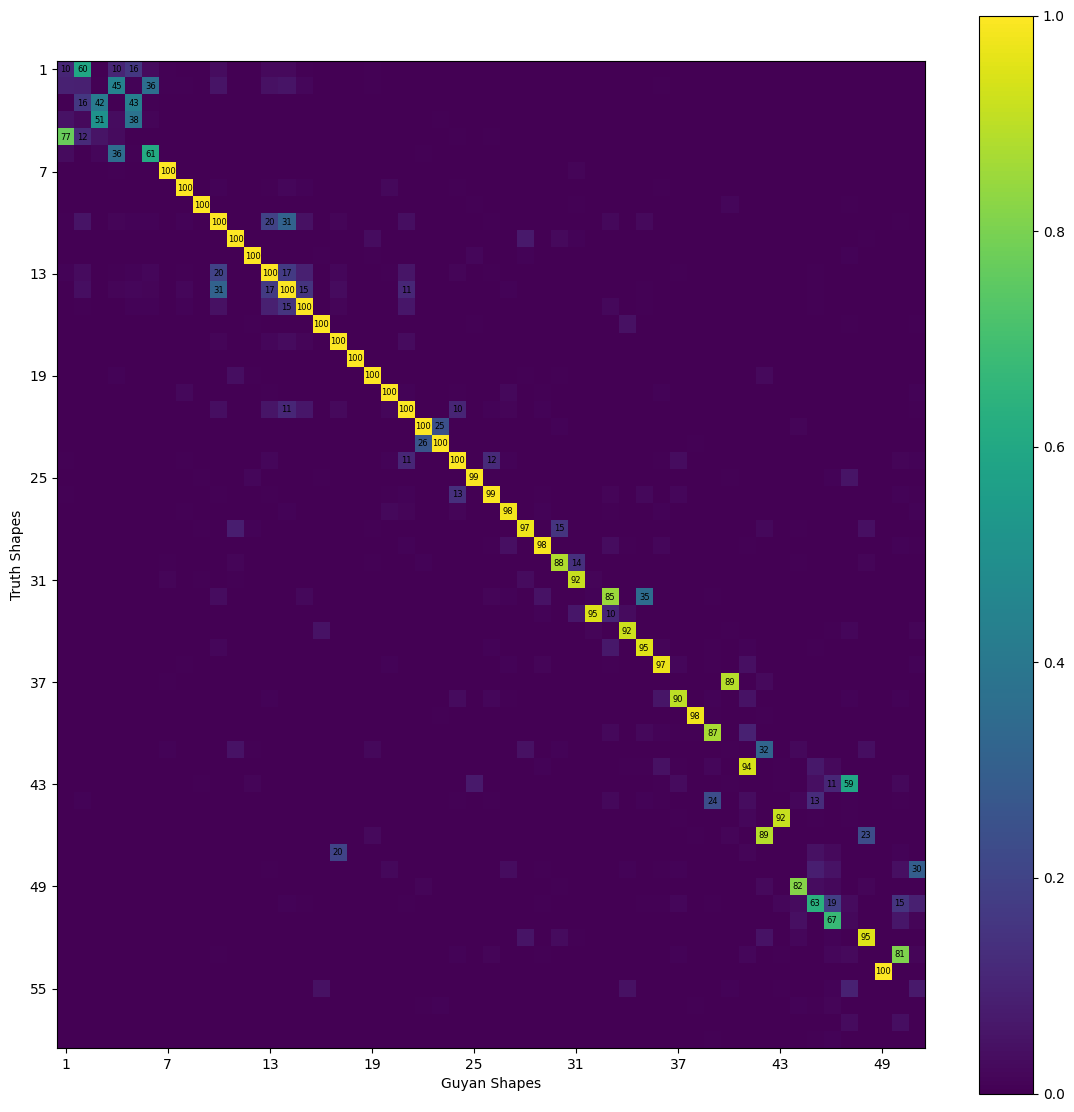

In [11]:
mac = sdpy.shape.mac(full_shapes,full_shapes_guyan)
fig,ax = plt.subplots(num='Guyan MAC',figsize=(14,14))
sdpy.matrix_plot(mac,ax=ax,text_size=6,)
ax.set_ylabel('Truth Shapes')
ax.set_xlabel('Guyan Shapes');

We can then find correspondences between finite element model and reduced shapes by selecting the maximum values of the MAC for each row.  Note that the rigid body modes will generall be linear combinations of one another, and therefore will look poor in the MAC regardless of their true accuracy, so we will ignore them.

Guyan Mode Table
  Mode  Freq 1 (Hz)  Freq 2 (Hz)  Freq Error  MAC
     1         0.64         0.64       -0.0%  100
     2         1.24         1.24       -0.0%  100
     3         2.25         2.25       -0.0%  100
     4         3.51         3.51       -0.0%  100
     5         3.63         3.63       -0.1%  100
     6         3.78         3.78       -0.0%  100
     7         6.40         6.40       -0.1%  100
     8         7.53         7.54       -0.2%  100
     9         9.82         9.82       -0.1%  100
    10        11.81        11.86       -0.4%  100
    11        12.91        12.96       -0.4%  100
    12        13.29        13.34       -0.3%  100
    13        14.49        14.56       -0.5%  100
    14        16.46        16.58       -0.7%  100
    15        17.42        17.50       -0.4%  100
    16        18.72        18.75       -0.2%  100
    17        20.21        20.29       -0.4%  100
    18        23.10        23.28       -0.8%  100
    19        24.50        24.96 

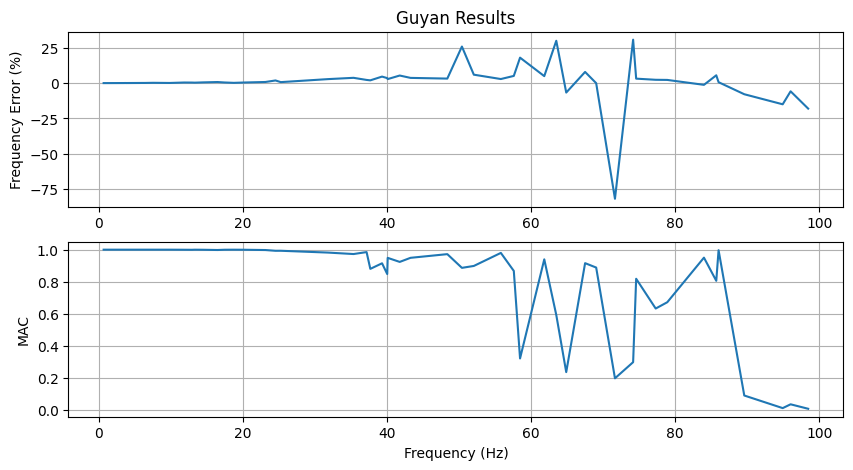

In [12]:
correspondences = (np.arange(mac.shape[0])[6:],np.argmax(mac,axis=-1)[6:])
truth_shapes_to_compare = full_shapes[correspondences[0]]
shapes_to_compare = full_shapes_guyan[correspondences[1]]
print('Guyan Mode Table')
print(sdpy.shape.shape_comparison_table(
    truth_shapes_to_compare,shapes_to_compare,damping_format=None,table_format='text'))
fig,ax = plt.subplots(2,1,num='Guyan Comparison',figsize=(10,5))
frequency_error = 100*((shapes_to_compare.frequency-truth_shapes_to_compare.frequency)
                       /truth_shapes_to_compare.frequency)
ax[0].plot(truth_shapes_to_compare.frequency,frequency_error)
ax[1].plot(truth_shapes_to_compare.frequency,mac[correspondences])
ax[0].set_title('Guyan Results')
ax[1].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel('Frequency Error (%)')
ax[1].set_ylabel('MAC')
ax[0].grid(True)
ax[1].grid(True)

### Dynamic Reduction
To try to improve the Guyan reduction by incorporating mass effects into the reduction, the Dynamic Reduction technique was developed.  In this technique, a single frequency is selected to include in the reduction, which will make the reduction "perfect" at that frequency.

A "Dynamic" stiffness matrix is created as

$$ \mathbf{D} = \mathbf{K} - (2 \pi f)^2\mathbf{M}$$

where $f$ is the frequency of interest.

The formula for the transformation is:

$$ \mathbf{T} = \begin{bmatrix} \mathbf{I} \\ -{\mathbf{D}_{dd}}^{-1}\mathbf{D}_{da}\end{bmatrix}$$

where the $a$-set degrees of freedom are the kept degrees of freedom in `reduction_dofs`, and the $d$-set degrees of freedom are the discarded set.

Dynamic reduction can be easily performed in SDynPy by using the [`reduce_dynamic`](#api:sdynpy.System.reduce_dynamic) method of the [`System`](#api:sdynpy.System) object.  The reduced systems can be combined identically to the full system by using the [`substructure_by_position`](#api:sdynpy.System.substructure_by_position) function.

In this case, we will set the frequency for the Dynamic reduction to be 1/4 the maximum frequency.

In [13]:
dynamic_frequency = maximum_frequency/4

system_dynamic = {}
component_shapes_dynamic = {}
for name,system_i in system.items():
    dofs = reduction_dofs[np.isin(reduction_dofs,system_i.coordinate)]
    system_dynamic[name] = system_i.reduce_dynamic(dofs,dynamic_frequency)
    # Compute modes and compare to original system
    component_shapes_dynamic[name] = system_dynamic[name].eigensolution(maximum_frequency=maximum_frequency)

full_system_dynamic,full_geometry_dynamic = sdpy.system.substructure_by_position(
    [system_dynamic[name] for name in names],[geometry[name] for name in names])

full_shapes_dynamic = full_system_dynamic.eigensolution(maximum_frequency=maximum_frequency)

We can compare the shapes again to the truth value using the MAC.

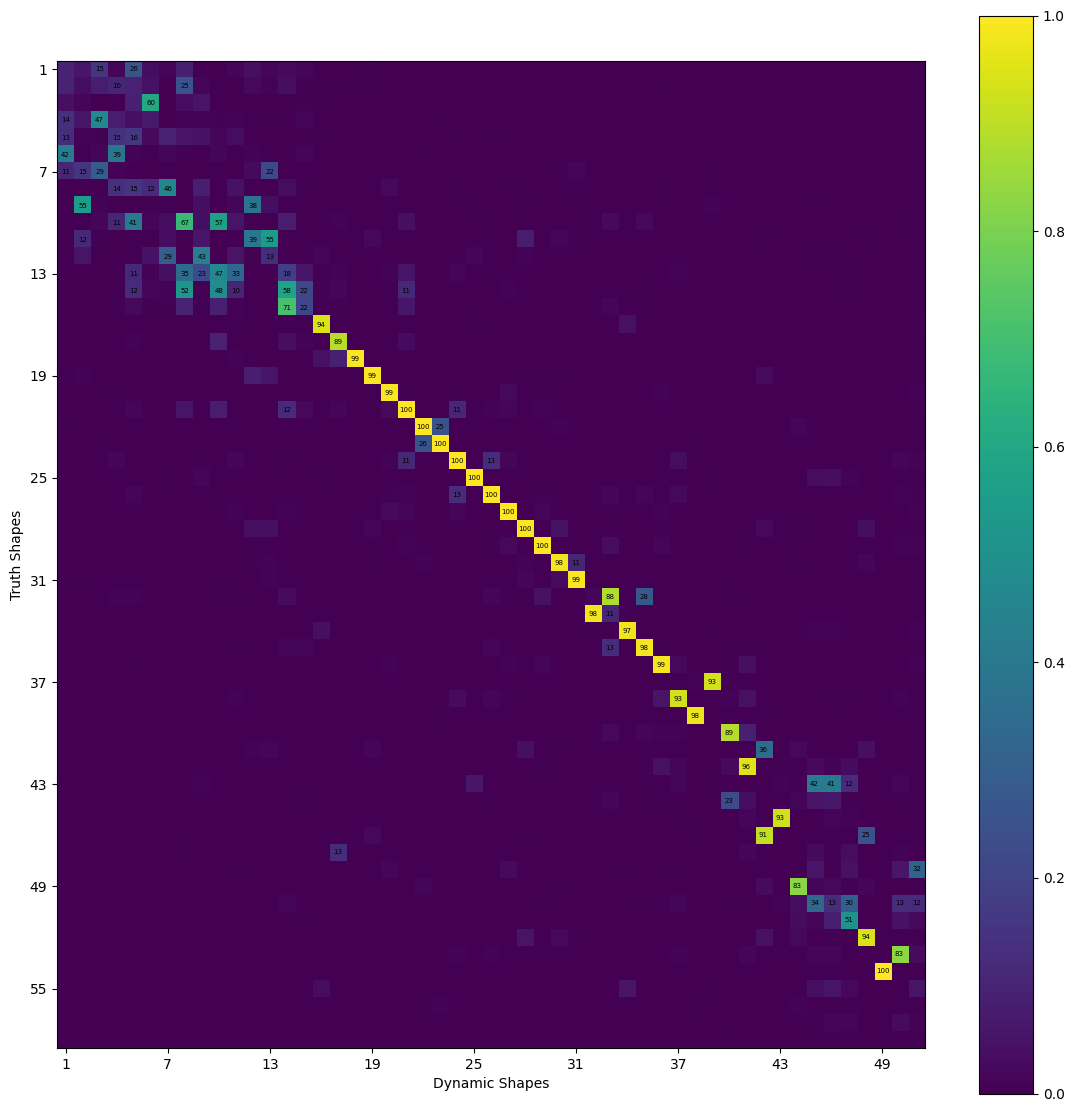

In [14]:
mac = sdpy.shape.mac(full_shapes,full_shapes_dynamic)
fig,ax = plt.subplots(num='Dynamic MAC',figsize=(14,14))
sdpy.matrix_plot(mac,ax=ax,text_size=5,)
ax.set_ylabel('Truth Shapes')
ax.set_xlabel('Dynamic Shapes');

Dynamic Mode Table
  Mode  Freq 1 (Hz)  Freq 2 (Hz)  Freq Error  MAC
     1         0.64         3.06      -78.9%   29
     2         1.24         4.86      -74.4%   46
     3         2.25         2.38       -5.5%   55
     4         3.51         5.52      -36.5%   67
     5         3.63         8.89      -59.2%   55
     6         3.78         6.45      -41.4%   43
     7         6.40         7.00       -8.6%   47
     8         7.53         9.98      -24.6%   58
     9         9.82         9.98       -1.7%   71
    10        11.81        12.48       -5.3%   94
    11        12.91        13.47       -4.2%   89
    12        13.29        13.60       -2.3%   99
    13        14.49        14.86       -2.5%   99
    14        16.46        16.70       -1.4%   99
    15        17.42        17.53       -0.6%  100
    16        18.72        18.74       -0.1%  100
    17        20.21        20.23       -0.1%  100
    18        23.10        23.11       -0.0%  100
    19        24.50        24.5

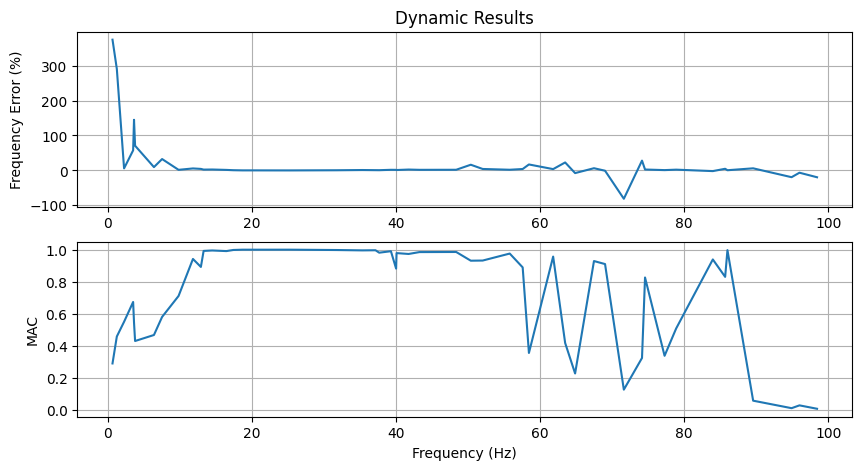

In [15]:
correspondences = (np.arange(mac.shape[0])[6:],np.argmax(mac,axis=-1)[6:])
truth_shapes_to_compare = full_shapes[correspondences[0]]
shapes_to_compare = full_shapes_dynamic[correspondences[1]]
print('Dynamic Mode Table')
print(sdpy.shape.shape_comparison_table(
    truth_shapes_to_compare,shapes_to_compare,damping_format=None,table_format='text'))
fig,ax = plt.subplots(2,1,num='Dynamic Comparison',figsize=(10,5))
frequency_error = 100*((shapes_to_compare.frequency-truth_shapes_to_compare.frequency)
                       /truth_shapes_to_compare.frequency)
ax[0].plot(truth_shapes_to_compare.frequency,frequency_error)
ax[1].plot(truth_shapes_to_compare.frequency,mac[correspondences])
ax[0].set_title('Dynamic Results')
ax[1].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel('Frequency Error (%)')
ax[1].set_ylabel('MAC')
ax[0].grid(True)
ax[1].grid(True)

While the results of the Dynamic Reduction do indeed result in perfect accuracy at the frequency of interest (25 Hz), the results elsewhere, particularly at the low frequency modes, are significantly degraded.

### Craig-Bampton Reduction
Perhaps the most famous reduction technique is the Craig-Bampton reduction.  The Craig-Bampton approach uses a set of interface modes of the boundary degrees of freedom along with fixed-base modes of each component to produce a very accurate substructure model with few degrees of freedom.

The transformation for this approach is:

$$ \mathbf{T} = \begin{bmatrix} \mathbf{\Phi}_{ii} & -{\mathbf{K}_{ii}}^{-1}\mathbf{K}_{ib} \\ \mathbf{0}_{bi} & \mathbf{I}_{bb}\end{bmatrix}$$

where the $i$-set is the "internal" degrees of freedom and the $b$-set is the "boundary" degrees of freedom.  The first column of the matrix represents the fixed-base modes, where the $b$-set of degrees of freedom are zero, and $\mathbf{\Phi}_{ii}$ represents the fixed base modes of the internal degrees of freedom.  The second column represents the interface modes, which are static deflection shapes computed by deflection a single boundary degree of freedom a unit amount while holding the others fixed (hence the identity matrix $\mathbf{I}_{bb})$ and computing the static deformations of the internal degrees of freedom due to that boundary motion, which is equal to $-{\mathbf{K}_{ii}}^{-1}\mathbf{K}_{ib}$.

For this approach, we must specify the boundary degrees of freedom and the number of fixed interface modes to retain.  In this case, we will keep a number of fixed base modes to result in an equivalent number of degrees of freedom in the reduced system compared to the previous Guyan and Dynamic reductions.  Craig-Bampton reduction can be easily performed in SDynPy by using the [`reduce_craig_bampton`](#api:sdynpy.System.reduce_craig_bampton) method of the [`System`](#api:sdynpy.System) object and providing the connection degrees of freedom and the number of fixed-base modes to keep.  Optionally, the reduction basis can also be returned as [`ShapeArray`](#api:sdynpy.ShapeArray) object so the transformation can be visualized.  The reduced systems can be combined identically to the full system by using the [`substructure_by_position`](#api:sdynpy.System.substructure_by_position) function.

In [16]:
system_cb = {}
component_shapes_cb = {}
for name,system_i in system.items():
    dofs = all_boundary_dofs[np.isin(all_boundary_dofs,system_i.coordinate)]
    n_fixed_base_modes = system_guyan[name].ndof - dofs.size
    system_cb[name],constraint_shapes = system_i.reduce_craig_bampton(
        dofs,n_fixed_base_modes,return_shape_matrix=True)
    geometry[name].plot_shape(constraint_shapes,plot_kwargs=plot_kwargs)
    # Compute modes and compare to original system
    component_shapes_cb[name] = system_cb[name].eigensolution(maximum_frequency=maximum_frequency)

full_system_cb,full_geometry_cb = sdpy.system.substructure_by_position(
    [system_cb[name] for name in names],[geometry[name] for name in names])

full_shapes_cb = full_system_cb.eigensolution(maximum_frequency=maximum_frequency)

|Mode Type | Fuselage | Wing | Tail |
| --- | --- | --- | --- |
|Fixed Base Mode|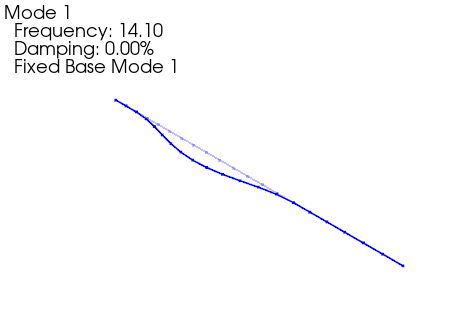|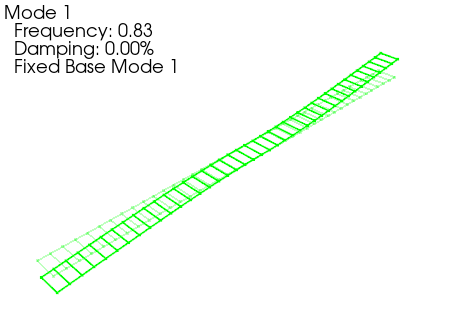|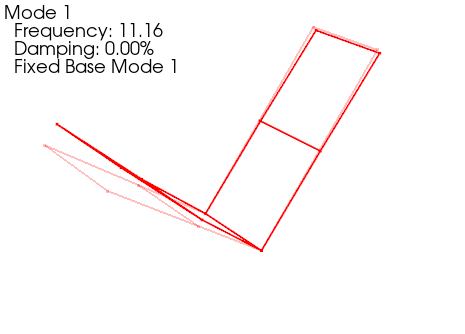|
|Constraint Mode|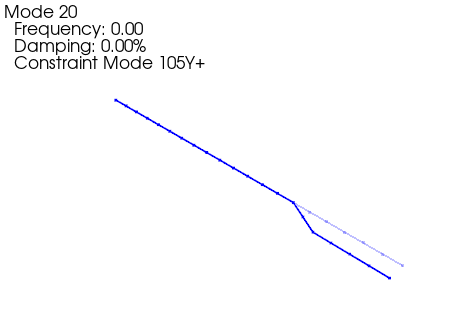|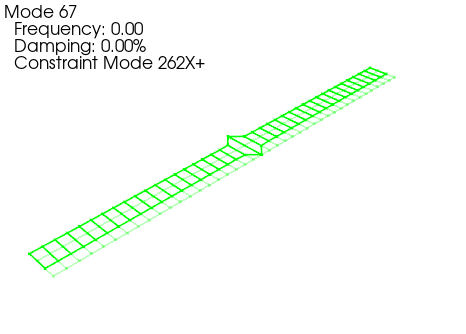|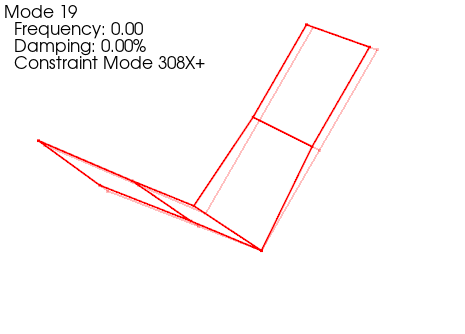|

We can compare the combined Craig-Bampton model against the Truth results to see how accurate it is.

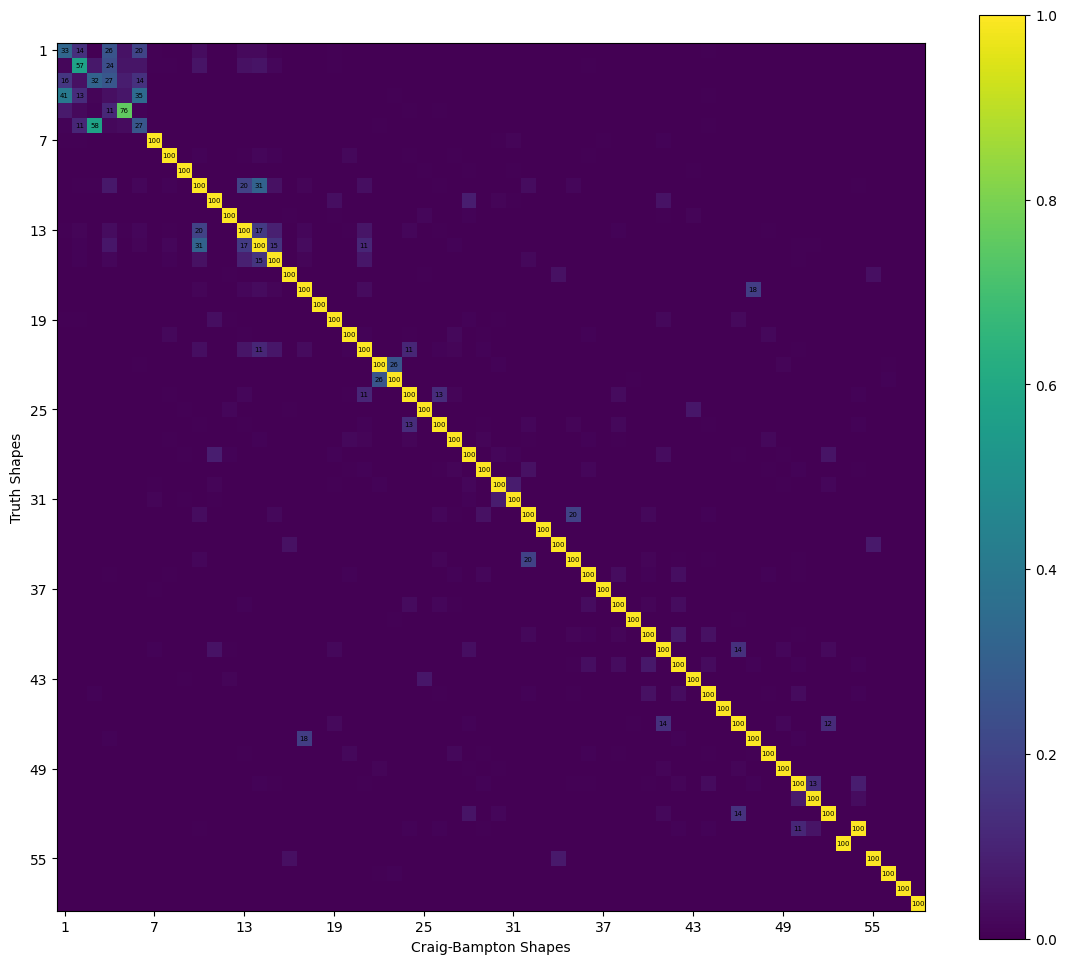

In [17]:
mac = sdpy.shape.mac(full_shapes,full_shapes_cb)
fig,ax = plt.subplots(num='Craig-Bampton MAC',figsize=(14,12))
sdpy.matrix_plot(mac,ax=ax,text_size=5,)
ax.set_ylabel('Truth Shapes')
ax.set_xlabel('Craig-Bampton Shapes');

Craig-Bampton Mode Table
  Mode  Freq 1 (Hz)  Freq 2 (Hz)  Freq Error  MAC
     1         0.64         0.64       -0.0%  100
     2         1.24         1.24       -0.0%  100
     3         2.25         2.25       -0.0%  100
     4         3.51         3.51       -0.0%  100
     5         3.63         3.63       -0.0%  100
     6         3.78         3.78       -0.0%  100
     7         6.40         6.40       -0.0%  100
     8         7.53         7.53       -0.0%  100
     9         9.82         9.82       -0.0%  100
    10        11.81        11.81       -0.0%  100
    11        12.91        12.91       -0.0%  100
    12        13.29        13.29       -0.0%  100
    13        14.49        14.49       -0.0%  100
    14        16.46        16.46       -0.0%  100
    15        17.42        17.43       -0.0%  100
    16        18.72        18.72       -0.0%  100
    17        20.21        20.21       -0.0%  100
    18        23.10        23.10       -0.0%  100
    19        24.50      

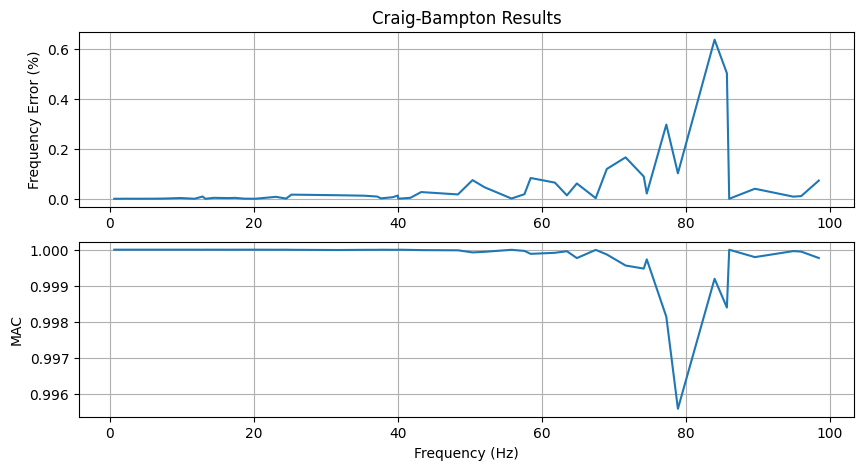

In [18]:
correspondences = (np.arange(mac.shape[0])[6:],np.argmax(mac,axis=-1)[6:])
truth_shapes_to_compare = full_shapes[correspondences[0]]
shapes_to_compare = full_shapes_cb[correspondences[1]]
print('Craig-Bampton Mode Table')
print(sdpy.shape.shape_comparison_table(
    truth_shapes_to_compare,shapes_to_compare,damping_format=None,table_format='text'))
fig,ax = plt.subplots(2,1,num='Craig-Bampton Comparison',figsize=(10,5))
frequency_error = 100*((shapes_to_compare.frequency-truth_shapes_to_compare.frequency)
                       /truth_shapes_to_compare.frequency)
ax[0].plot(truth_shapes_to_compare.frequency,frequency_error)
ax[1].plot(truth_shapes_to_compare.frequency,mac[correspondences])
ax[0].set_title('Craig-Bampton Results')
ax[1].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel('Frequency Error (%)')
ax[1].set_ylabel('MAC')
ax[0].grid(True)
ax[1].grid(True)

Clearly the Craig-Bampton approach is much more accurate than the Guyan or Dynamic approaches.

### Component Mode Synthesis
The final reduction performed for this work is a modal reduction.  Each component system will be reduced down to its component mode shapes.  The transformation for this reduction is simply

$$ \mathbf{T} = \mathbf{\Phi} $$ 

where $\mathbf{\Phi}$ is the mode shapes of the system.  To keep things "fair" we will use the same number of modes as there were degrees of freedom in the previous cases to ensure all reduced systems are the same size.

In [19]:
system_cms = {}
component_shapes_cms = {}
for name,system_i in system.items():
    system_cms[name] = system_i.eigensolution(num_modes = system_guyan[name].ndof,return_shape=False)
    # Compute modes and compare to original system
    component_shapes_dynamic[name] = system_cms[name].eigensolution(maximum_frequency=maximum_frequency)

full_system_cms,full_geometry_cms = sdpy.system.substructure_by_position(
    [system_cms[name] for name in names],[geometry[name] for name in names])

full_shapes_cms = full_system_cms.eigensolution(maximum_frequency=maximum_frequency)

We can compare these shapes to the truth values to understand how good the reduction performed.

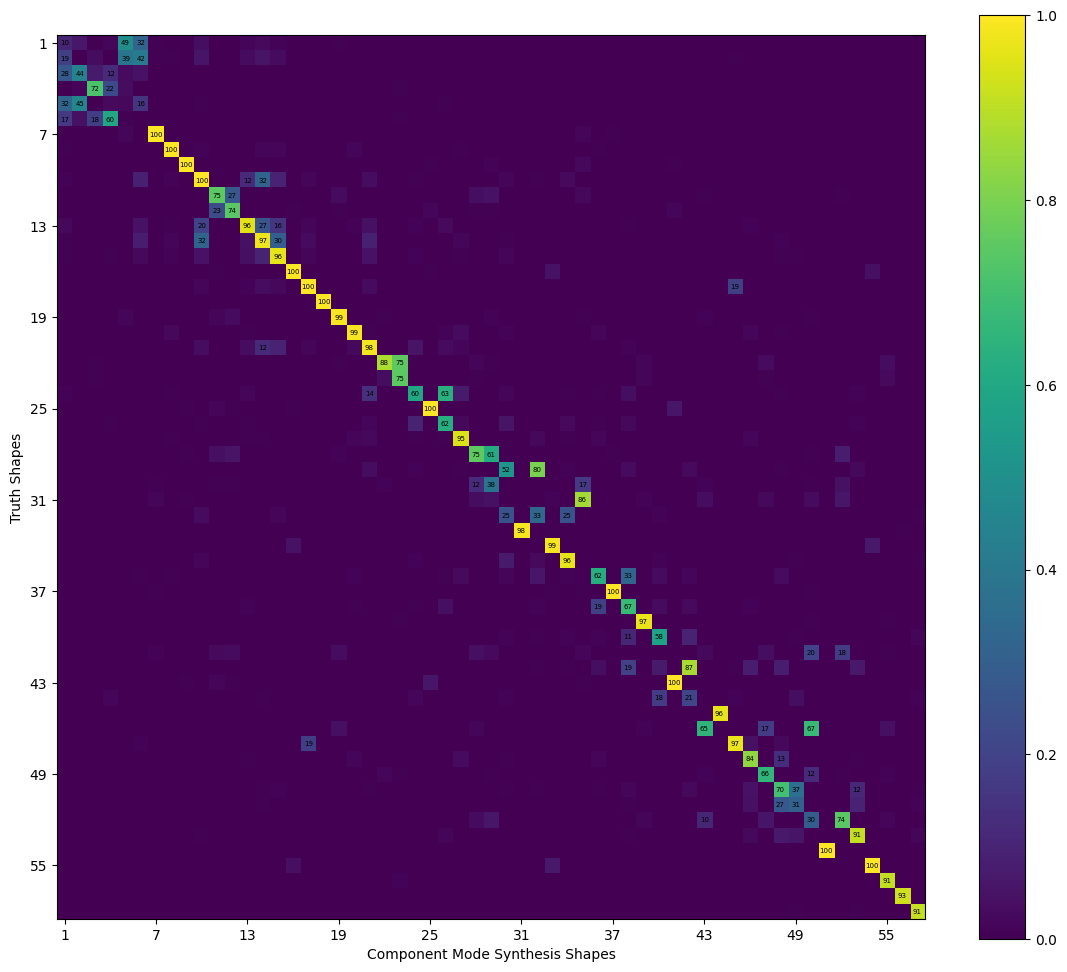

In [20]:
mac = sdpy.shape.mac(full_shapes,full_shapes_cms)
fig,ax = plt.subplots(num='Component Mode Synthesis MAC',figsize=(14,12))
sdpy.matrix_plot(mac,ax=ax,text_size=5,)
ax.set_ylabel('Truth Shapes')
ax.set_xlabel('Component Mode Synthesis Shapes');

Component Mode Synthesis Mode Table
  Mode  Freq 1 (Hz)  Freq 2 (Hz)  Freq Error  MAC
     1         0.64         0.66       -2.2%  100
     2         1.24         1.24       -0.0%  100
     3         2.25         2.37       -5.2%  100
     4         3.51         3.63       -3.3%  100
     5         3.63         3.74       -3.0%   75
     6         3.78         3.86       -2.2%   74
     7         6.40         6.51       -1.7%   96
     8         7.53         8.07       -6.7%   97
     9         9.82        10.01       -2.0%   96
    10        11.81        11.83       -0.1%  100
    11        12.91        12.95       -0.3%  100
    12        13.29        13.48       -1.4%  100
    13        14.49        15.60       -7.1%   99
    14        16.46        16.61       -0.9%   99
    15        17.42        18.55       -6.1%   98
    16        18.72        19.59       -4.5%   88
    17        20.21        21.47       -5.9%   75
    18        23.10        27.62      -16.4%   63
    19        

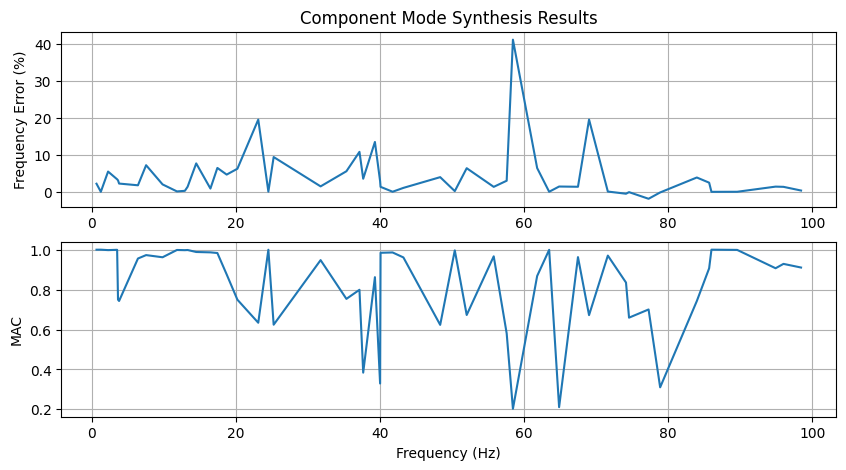

In [21]:
correspondences = (np.arange(mac.shape[0])[6:],np.argmax(mac,axis=-1)[6:])
truth_shapes_to_compare = full_shapes[correspondences[0]]
shapes_to_compare = full_shapes_cms[correspondences[1]]
print('Component Mode Synthesis Mode Table')
print(sdpy.shape.shape_comparison_table(
    truth_shapes_to_compare,shapes_to_compare,damping_format=None,table_format='text'))
fig,ax = plt.subplots(2,1,num='Component Mode Synthesis Comparison',figsize=(10,5))
frequency_error = 100*((shapes_to_compare.frequency-truth_shapes_to_compare.frequency)
                       /truth_shapes_to_compare.frequency)
ax[0].plot(truth_shapes_to_compare.frequency,frequency_error)
ax[1].plot(truth_shapes_to_compare.frequency,mac[correspondences])
ax[0].set_title('Component Mode Synthesis Results')
ax[1].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel('Frequency Error (%)')
ax[1].set_ylabel('MAC')
ax[0].grid(True)
ax[1].grid(True)

## Comparison of Results

Finally, we will compare the results of the different reduction methods.  For each system, we will plot the reduced system mode shapes overlaying the truth system's mode shapes.  We will also produce a plot with all frequency and shape errors, so the data can be compared.

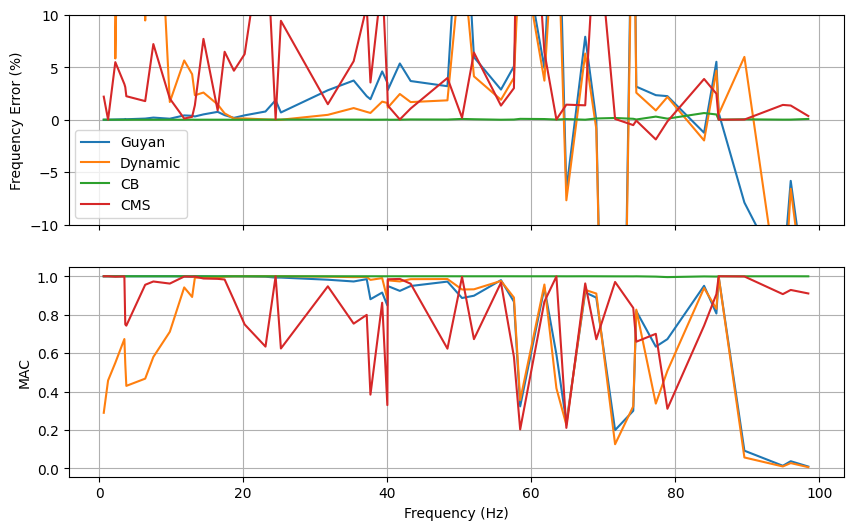

In [22]:
frequency_errors = []
shape_macs = []
names = ['Guyan','Dynamic','CB','CMS']
for name,system_i,geometry_i in zip(names,
                                    [full_system_guyan,full_system_dynamic,
                                     full_system_cb,full_system_cms],
                                    [full_geometry_guyan,full_geometry_dynamic,
                                     full_geometry_cb,full_geometry_cms]):
    # Compute mode shapes
    shapes_i = system_i.eigensolution(maximum_frequency = maximum_frequency)
    shapes_i.comment1 = name
    # Compute MAC
    mac = sdpy.shape.mac(full_shapes,shapes_i)
    # Find best reduced shape to match the truth shapes
    correspondences = (np.arange(mac.shape[0])[6:],np.argmax(mac,axis=-1)[6:])
    # Reduce the shapes using correspondences
    full_shapes_to_compare = full_shapes[correspondences[0]]
    shapes_i_to_compare = shapes_i[correspondences[1]]
    # Compute whether or not we need to flip signs on the shapes to get them to overlay
    flip_signs = sdpy.shape.shape_alignment(full_shapes_to_compare,
                                            shapes_i_to_compare)
    shapes_i_to_compare.shape_matrix *= flip_signs[:,np.newaxis]
    # Overlay common shapes
    compare_geom,compare_shape = sdpy.shape.overlay_shapes(
        (full_geometry,geometry_i),(full_shapes_to_compare,shapes_i_to_compare),[1,7])
    # Put metadata into the shape comments
    compare_shape.comment1 = name
    compare_shape.comment2 = ['Truth (Blue): {:0.2f} Hz, Predicted (Green): {:0.2f} Hz'.format(t,p)
                              for t,p in zip(full_shapes_to_compare.frequency,
                                             shapes_i_to_compare.frequency)]
    compare_shape.comment3 = ['Frequency Error: {:0.2f}%'.format(100*(p-t)/t)
                              for t,p in zip(full_shapes_to_compare.frequency,
                                             shapes_i_to_compare.frequency)]
    compare_shape.comment4 = ['MAC: {:0.2f}'.format(mac[i,j]) for i,j in zip(*correspondences)]
    # Plot the overlaid shapes
    compare_geom.plot_shape(compare_shape,plot_kwargs,undeformed_opacity=0)
    # Store data to plot later
    shape_macs.append(mac[correspondences])
    frequency_errors.append([100*(p-t)/t for t,p in zip(full_shapes_to_compare.frequency,
                                                         shapes_i_to_compare.frequency)])
frequency_errors = np.array(frequency_errors)
shape_macs = np.array(shape_macs)
fig,ax = plt.subplots(2,num='Reduction Comparison',sharex=True,figsize=(10,6))
ax[0].plot(full_shapes[6:].frequency,frequency_errors.T)
ax[0].set_ylim(-10,10)
ax[1].plot(full_shapes[6:].frequency,shape_macs.T)
ax[1].set_xlabel('Frequency (Hz)')
ax[0].set_ylabel('Frequency Error (%)')
ax[1].set_ylabel('MAC')
ax[0].legend(names)
ax[0].grid(True)
ax[1].grid(True)

| Mode | Guyan | Dynamic | Craig Bampton | CMS |
| ---  |  ---  |  ---    |    ---        | --- |
| 0.64 Hz | 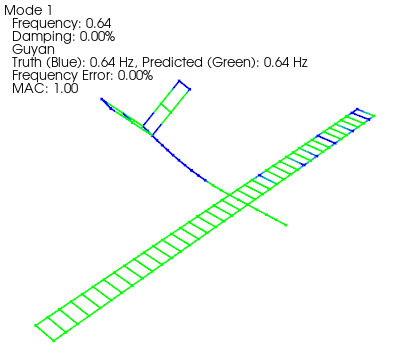 | 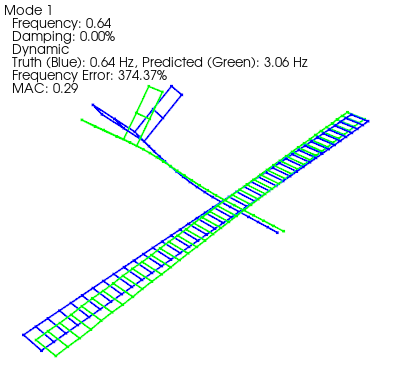 | 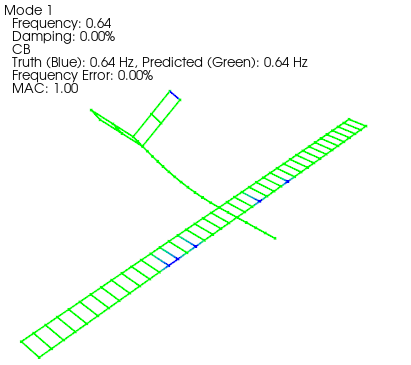 | 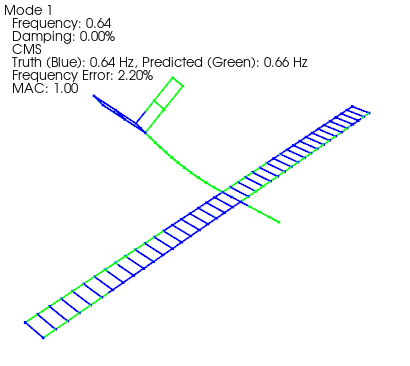 |
| 25.24 Hz | 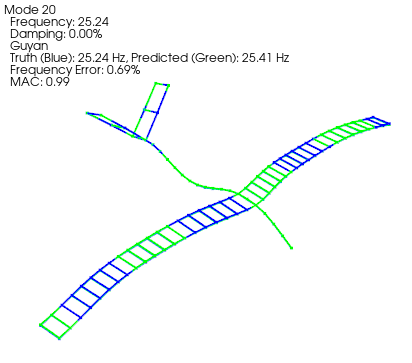 | 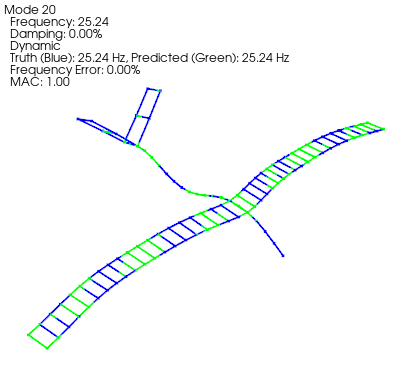 | 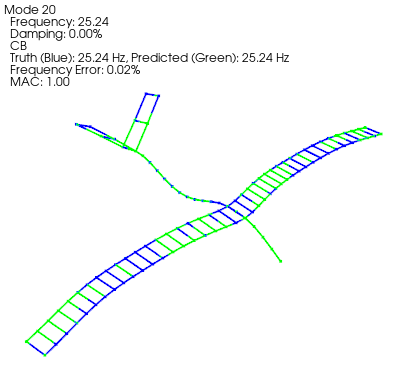 | 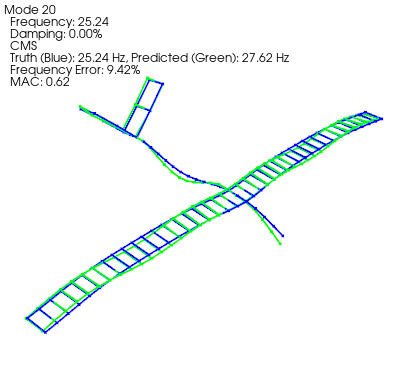 |
| 52.04 Hz | 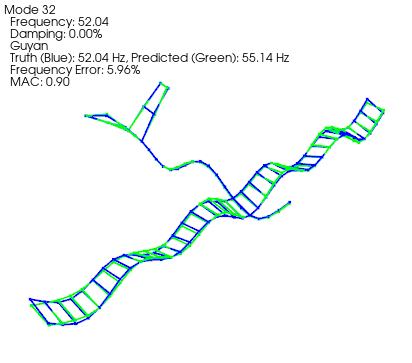 | 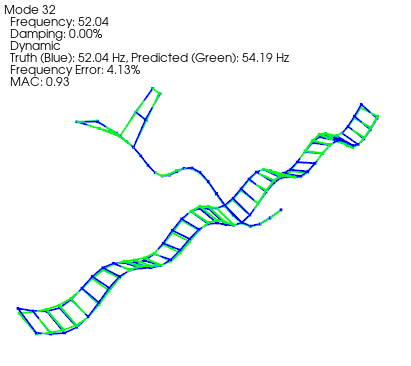 | 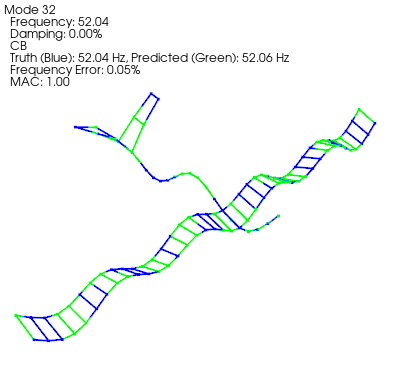 | 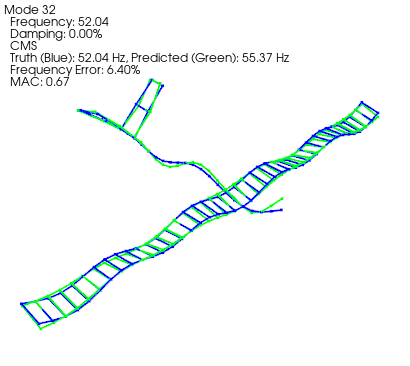 | 
| 78.90 Hz | 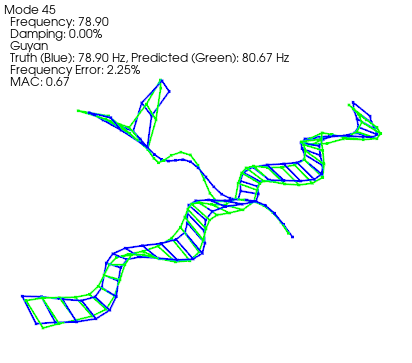 | 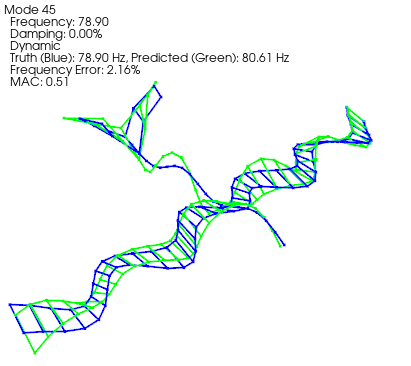 | 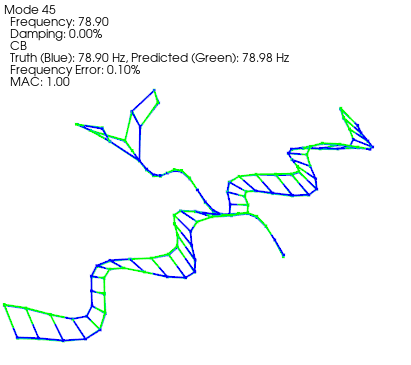 | 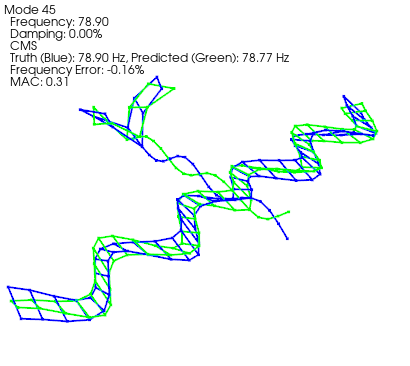 |





The results show the best reduced model is clearly the Craig-Bampton model.  It has very low frequency errors and very high MAC values across the entire frequency band of interest.  The Guyan Reduction does surprisingly well up to approximately 40 Hz considering it only relies on stiffness effects for its transformation, though this potentially due to the fairly large number of kept degrees of freedom.  The model reduced by the Dynamic Reduction has very poor performance at frequencies below the specified frequency to match.  Perfect results are obtained at this frequency, after which it behaves similarly to the Guyan reduction.  This makes some amount of sense, because the Guyan Reduction could be considered a special case of the Dynamic Reduction, where the specified frequency is set to 0 Hz.  Finally, the component mode synthesis approach struggled over much of the frequency band.  This was expected, as the free mode shapes used in the expansion would not contain the correct basis shapes to handle the deflections in the assembled case.  For example, there would be nearly zero strain at the end of the fuselage where the tail attaches.  However, in the assembled case, there will be strain at that location due to the reaction force from the tail.

This example has shown the ability to perform reduction and substructuring operations with SDynPy.  SDynPy handled all of the bookkeeping for us, allowing us to focus more on the different approaches, rather than getting bogged down in the code.